# 03 - Topic Model Evaluation

Compares the fine-tuned and baseline BERTopic models using:
1. Pairwise cosine similarity of topic embeddings
2. Topic diversity (OCTIS)
3. Topic coherence (OCTIS c_npmi)

In [1]:
import sys
sys.path.append("../functions")

import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from octis.evaluation_metrics.coherence_metrics import Coherence
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

from config import FINETUNED_MODEL_DIR, BASELINE_MODEL_DIR, FIGURES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper functions

In [2]:
def load_topics_and_embeddings(model_dir, stance="object"):
    """Load topic representations and embeddings from a model output directory."""
    topics = pd.read_csv(model_dir / f"{stance}_topics.csv")
    topic_list = [ast.literal_eval(r) for r in topics["Representation"]]
    embeddings = pd.read_csv(model_dir / f"{stance}_topic_embeddings.csv")
    return topic_list, embeddings

def cosine_stats(embeddings, threshold=0.85):
    """Return mean similarity and % of pairs above threshold."""
    cs = cosine_similarity(embeddings, embeddings)
    n  = len(embeddings)
    n_pairs = math.comb(n, 2)
    above   = (np.sum(cs > threshold) - n) // 2  # exclude diagonal
    return {
        "mean_similarity": round(float(np.mean(cs)), 4),
        "pct_above_threshold": round(above / n_pairs * 100, 2) if n_pairs else 0.0,
    }

def compute_diversity_scores(topic_list, metric):
    return [metric.score({"topics": topic_list[:i+1]}) for i in range(len(topic_list))]

def compute_coherence_scores(topic_list, metric):
    return [metric.score({"topics": topic_list[:i+1]}) for i in range(len(topic_list))]

## Load model outputs

In [3]:
object_topics_ft,  embeddings_ft  = load_topics_and_embeddings(FINETUNED_MODEL_DIR)
object_topics_base, embeddings_base = load_topics_and_embeddings(BASELINE_MODEL_DIR)

print(f"Fine-tuned model: {len(object_topics_ft)} topics")
print(f"Baseline model:   {len(object_topics_base)} topics")

Fine-tuned model: 100 topics
Baseline model:   100 topics


## Cosine similarity comparison

In [4]:
stats_ft   = cosine_stats(embeddings_ft)
stats_base = cosine_stats(embeddings_base)

print("Fine-tuned: ", stats_ft)
print("Baseline:   ", stats_base)

Fine-tuned:  {'mean_similarity': 0.1283, 'pct_above_threshold': 0.04}
Baseline:    {'mean_similarity': 0.2738, 'pct_above_threshold': 0.02}


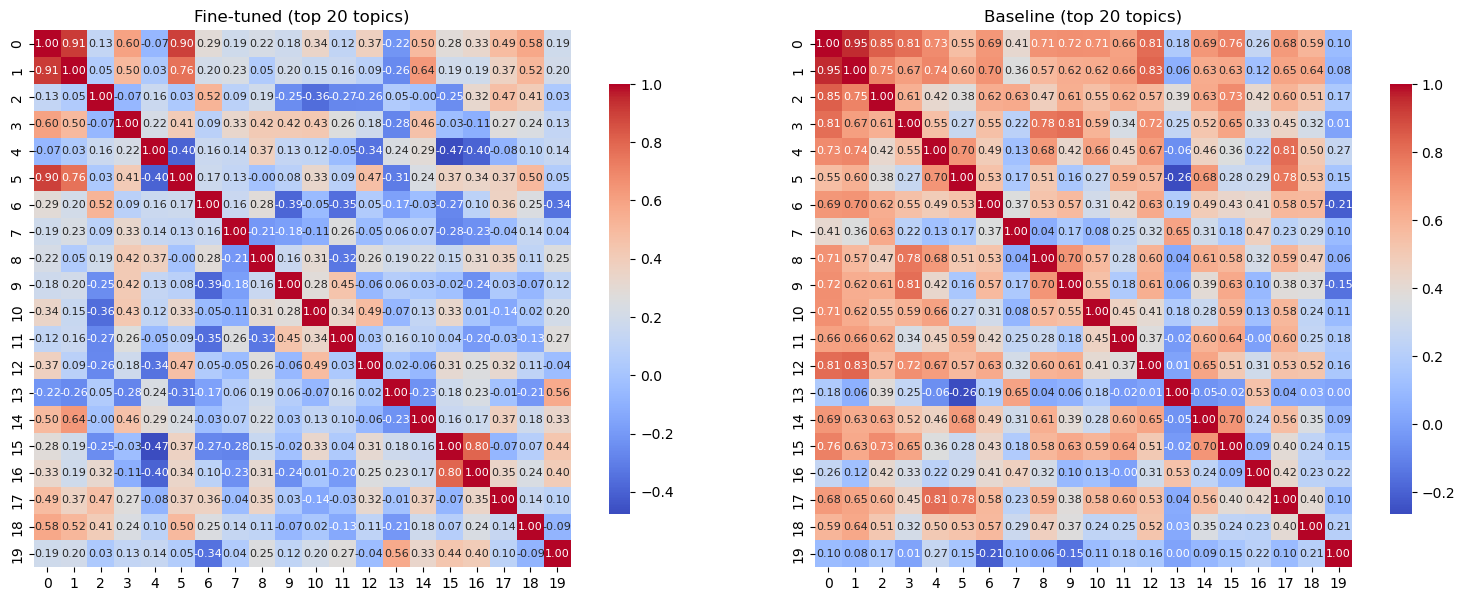

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, embeds, title in zip(
    axes,
    [embeddings_ft.values[:20, :20], embeddings_base.values[:20, :20]],
    ["Fine-tuned (top 20 topics)", "Baseline (top 20 topics)"],
):
    cs = cosine_similarity(embeds, embeds)
    sns.heatmap(cs, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
                square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
    ax.set_title(title)
    
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_cosine_similarity_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Diversity & coherence scores

In [6]:
div_metric = TopicDiversity(topk=3)
coh_metric_ft   = Coherence(texts=object_topics_ft,   topk=10, measure="c_npmi")
coh_metric_base = Coherence(texts=object_topics_base, topk=10, measure="c_npmi")

scores = {
    "fine_tuned":  {"diversity": div_metric.score({"topics": object_topics_ft}),
                    "coherence": coh_metric_ft.score({"topics": object_topics_ft})},
    "baseline":    {"diversity": div_metric.score({"topics": object_topics_base}),
                    "coherence": coh_metric_base.score({"topics": object_topics_base})},
}
pd.DataFrame(scores).T

,diversity,coherence
fine_tuned,0.726667,0.637576
baseline,0.916667,0.856187


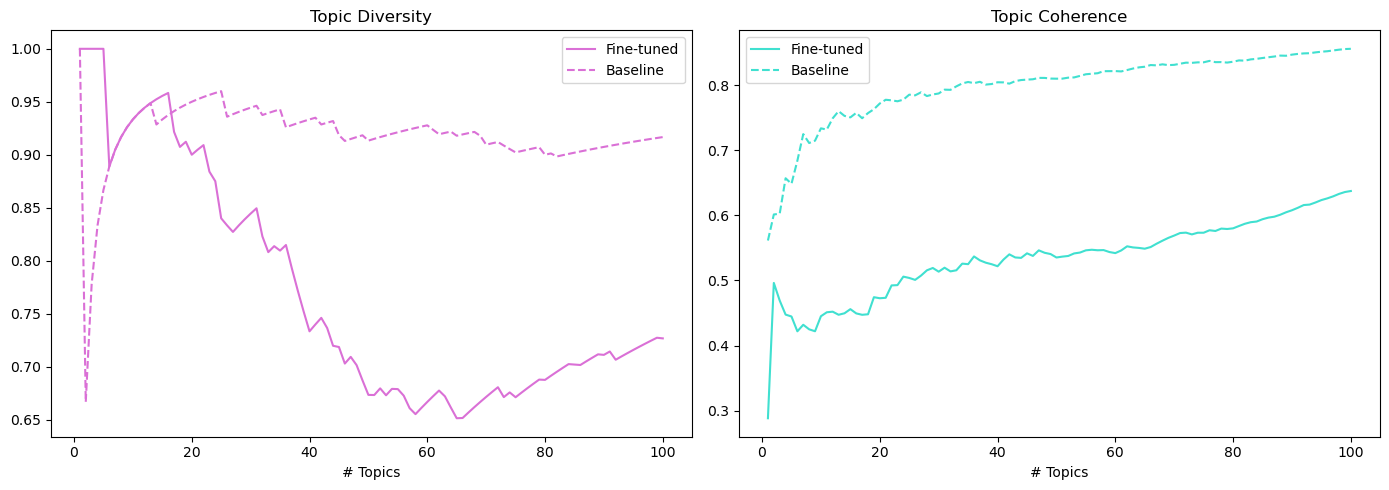

In [7]:
# Scores as a function of number of topics
div_scores_ft   = compute_diversity_scores(object_topics_ft,   div_metric)
div_scores_base = compute_diversity_scores(object_topics_base, div_metric)
coh_scores_ft   = compute_coherence_scores(object_topics_ft,   coh_metric_ft)
coh_scores_base = compute_coherence_scores(object_topics_base, coh_metric_base)

n_ft   = range(1, len(object_topics_ft)   + 1)
n_base = range(1, len(object_topics_base) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(n_ft,   div_scores_ft,   label="Fine-tuned", color="orchid")
axes[0].plot(n_base, div_scores_base, label="Baseline",   color="orchid", linestyle="--")
axes[0].set_title("Topic Diversity"); axes[0].set_xlabel("# Topics"); axes[0].legend()

axes[1].plot(n_ft,   coh_scores_ft,   label="Fine-tuned", color="turquoise")
axes[1].plot(n_base, coh_scores_base, label="Baseline",   color="turquoise", linestyle="--")
axes[1].set_title("Topic Coherence"); axes[1].set_xlabel("# Topics"); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_div_coherence_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()

## Cross-model topic similarity

In [8]:
# Re-encode both topic lists in a shared embedding space
shared_model = SentenceTransformer("all-MiniLM-L6-v2")
emb_ft_shared   = shared_model.encode(object_topics_ft,   convert_to_tensor=True).cpu()
emb_base_shared = shared_model.encode(object_topics_base, convert_to_tensor=True).cpu()

cs_cross = cosine_similarity(emb_ft_shared, emb_base_shared)
for threshold in [0.75, 0.85]:
    similar = int((cs_cross > threshold).sum())
    print(f"Similar pairs (threshold={threshold}): {similar}")

Similar pairs (threshold=0.75): 20
Similar pairs (threshold=0.85): 9
